<a href="https://colab.research.google.com/github/irfanrois75-dotcom/Visi-Komputer/blob/main/UTS_VISKOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving gambar bangun.png to gambar bangun.png
=== HASIL EKSTRAKSI FITUR ===

Objek 1
Area: 13739.5
Perimeter: 467.91377556324005
Centroid: (177, 569)

Objek 2
Area: 19037.0
Perimeter: 544.0731549263
Centroid: (722, 578)

Objek 3
Area: 17281.5
Perimeter: 762.4234427213669
Centroid: (177, 358)

Objek 4
Area: 40091.5
Perimeter: 782.1391710042953
Centroid: (439, 347)

Objek 5
Area: 36613.0
Perimeter: 766.5239423513412
Centroid: (723, 359)

Objek 6
Area: 21904.0
Perimeter: 592.0
Centroid: (723, 142)

Objek 7
Area: 35953.0
Perimeter: 782.4852812290192
Centroid: (439, 142)


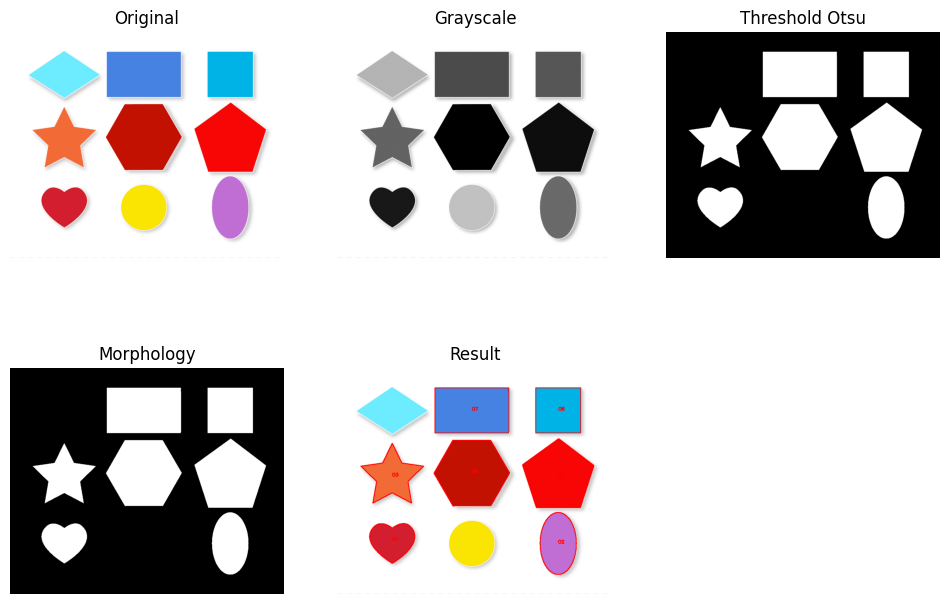

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# upload gambar
uploaded = files.upload()

# baca gambar
img = cv2.imread(list(uploaded.keys())[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Grayscale (sesuai paper)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. OTSU Thresholding (inti paper)
_, thresh = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# 3. Morphology (opsional tapi ada di paper)
kernel = np.ones((3,3), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# 4. Contour detection (untuk fitur)
contours, _ = cv2.findContours(
    morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

# gambar hasil
output = img_rgb.copy()

print("=== HASIL EKSTRAKSI FITUR ===")

for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    # centroid
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    print(f"\nObjek {i+1}")
    print("Area:", area)
    print("Perimeter:", perimeter)
    print("Centroid:", (cx, cy))

    # gambar kontur
    cv2.drawContours(output, [cnt], -1, (255,0,0), 2)
    cv2.putText(output, f"O{i+1}", (cx, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

# tampilkan hasil
titles = ['Original', 'Grayscale', 'Threshold Otsu', 'Morphology', 'Result']
images = [img_rgb, gray, thresh, morph, output]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()